# Selecting Event Samples

## Event Data

We will use [pandas](https://pandas.pydata.org), a ubiquitous python _DataFrame_ analysis library, to investigate the results of a _partial_ experimental simulation and, later, write the final missing step in the simulate using pandas. Because pandas is such a central tool in data science (while actually being less commonly used in HEP), you should be able to use a search engine to find additional help with any issues encountered. But, please do also ask if you get too stuck!

We have provided two data files, one contains simulated neutrino interactions ([Events](./Glossary.ipynb#event)) occuring in a muon neutrino beam and one contains events simulated in a muon antineutrino beam. Both correspond to interactions taking place in an experiment's _far detector_ and so even though the simulated neutrino beam initially only contained muon (anti)neutrinos, the events here are simulated with both muon and electron flavor neutrinos to allow you to fully simulate and study an oscillation experiment.

In [4]:
import pandas as pa

simulated_events_nu_mode = pa.read_csv("neutrino_mode_events.csv")
simulated_events_antinu_mode = pa.read_csv("antineutrino_mode_events.csv")

# If the object is left on the last line of the cell, Jupyter will show the dataframe
simulated_events_nu_mode

,event_num,pid_nu,E_nu,is_CC,pid_lep,E_lepton,T_proton,num_pi0,E_pi0,num_cpi,T_cpi,E_nu_rec_true
0,59738,14,3.8461,1,13,3.7635,0.0815,0,0.0000,0,0.0000,3.8449
1,158084,12,2.9509,1,11,1.0026,1.5843,1,0.3705,0,0.0000,2.9574
2,32198,14,3.2742,1,13,1.8521,0.0216,0,0.0000,1,0.1168,2.1300
3,161645,12,1.0227,1,11,0.4851,0.2482,0,0.0000,1,0.1373,1.0102
4,54457,14,4.2643,0,14,0.0000,0.0000,1,0.8725,1,0.5417,1.5538
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,99182,14,1.9277,1,13,1.8782,0.0100,0,0.0000,0,0.0000,1.8883
199996,18774,14,12.0554,1,13,4.1297,0.3121,1,0.4174,4,4.4273,9.8444
199997,122037,12,17.7805,1,11,9.9706,0.0000,1,1.3020,3,5.0586,16.7497
199998,88162,14,3.4650,0,14,0.0000,0.1296,0,0.0000,0,0.0000,0.1296


Look at the event data table above: Each row corresponds to a single simulated neutrino interaction (an _event_), and each column corresponds to a property of that event. A description of each event property follows:
* `event_num`: An index corresponding to the order of simulation, as events are entirely independent this property is irrelevant for our simulation.
* `pid_nu`: The [Particle IDentifier](./GLossary.ipynb#pid) for the incoming neutrino. This tells us the neutrino [Flavor](./Glossary.ipynb#flavor): electron or muon (or tau, but we wont see any tau neutrinos in this project).
* `E_nu`: The [Total Energy](./Glossary.ipynb#energy) of the incoming neutrino.
* `is_CC`: Whether the interaction was [Charged Current](./Glossary.ipynb#cc) or Neutral Current.
* `pid_lep`: The [Particle IDentifier](./Glossary.ipynb#pid) for the lepton that leaves the interaction.
* `E_lepton`: The [Total Energy](./Glossary.ipynb#energy) for the lepton that leaves the interaction.
* `T_proton`: The sum of the [Kinetic Energies](./Glossary.ipynb#energy) of all protons that leave the interaction.
* `num_pi0`: The number of [Neutral Pions]() that leave the interaction.
* `E_pi0`: The sum of the [Total Energies](./Glossary.ipynb#energy) of all neutral pions that leave the interaction.
* `num_cpi`: The number of [Charged Pions]() that leave the interaction.
* `T_cpi`: The sum of the [Kinetic Energies](./Glossary.ipynb#energy) of all [Charged Pions]() that leave the interaction.
* `E_nu_rec_true`: The [Observable Energy](./Glossary.ipynb#observable) of the event that might be seen by a _perfect_ charged particle detector. This is a function of the energies of some of the particles that leave the interaction. Not all particles are easily visible in our detector, _e.g._ it is very difficult to reliably measure the energy of neutrons that leave an interaction and impossible to measure the energy of a neutrino that leaves the interaction as the probability of it re-interacting in the detector is functionally 0.

All of the information in this table should be considered simulation [Truth](./Glossary.ipynb#truth). Even the properties that might appear to be _observable_, like the total energy of neutral pions that are clearly visible in our detectors, in reality, detectors are never _perfect_ and always include some measurement error, or _detector smearing_, which is not included in this simulation. A bit later we will develop our own simple model of detector smearing and thus provide the final stage of the experiment simulation.

## What to do with all this data?
Particle physicists try to learn about the physical laws that govern the interactions of fundamental particles, in our case, neutrinos. The details of each interaction is, as far as we currently understand, random, but as we study many similar interactions we see patterns appear in the data. The way we learn about the physical laws is to try and build mathematical models that can accurately predict these patterns.

We will use [Histograms](./Glossary.ipynb#histograms) to analyse samples of interactions to try and build up an understanding of important patterns in the simulation, and then use this understanding to analyse 'data', where we cannot _cheat_ by looking at the [Truth](./Glossary.ipynb#truth) information. The results of our data analysis will be a measurement of a fundamental property of neutrinos and just might be able to tell us some new fundamental truth about nature and how the universe came to exist.

## My First Histogram

We can make histograms directly from pandas, like below:

<Axes: ylabel='Frequency'>

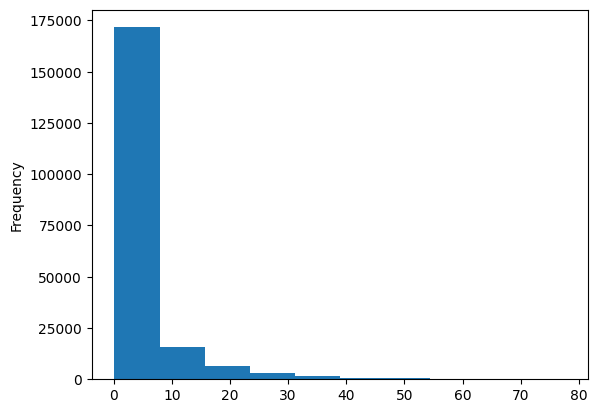

In [5]:
simulated_events_nu_mode["E_nu"].plot(kind='hist')

This is correct, the data has been sorted such that the number of rows with `E_nu` in a given _bin_ can be read off the above plot. However, it seems that almost all of our data falls in the first bin that spans $0 < E_\nu < 8$ GeV. Under the hood, pandas is using matplotlib and numpy to produce this plot, we will see very soon that our lives will be made easier by having more control and using those tools directly, but for now, lets play with the size and extent of the bins and see if we can find a scheme that might give us more useful information. We can change the binning scheme, as below, where we are using the numpy function `linspace` to generate a number of bin edges that are linearly spaced between two end points, as you can see in the following print out:

In [11]:
import numpy as np

# if you want bins of 1 GeV wide you will need 1 more edge than the range
#   as this function generates the bin edges, not the bins themselves. It
#   is equivalent to placing fence posts and the bins being the fence
#   between them, you always need one more post than fence because each
#   end needs a post.
np.linspace(start=0, stop=55, num=56)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55.])

We will use a number of other ubiquitous python libraries in this analysis, mostly: [numpy](), [matplotlib](), and [scipy](). You don't need to know anything about these tools already, but, like with pandas, you should be able to find help for any problems encountered via search engine results. In addition, we provide a few helpful tools so that you can get to analysis quickly, the code for these tools can be found in the [proj_utils](./proj_utils/__init__.py) module, but the hope is that you shouldn't need to see the details once you know how to use them.